<a href="https://colab.research.google.com/github/xsokolovae1/ml-supervised-learning/blob/main/KNN/KNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame = False)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [22]:
X, y = mnist.data, mnist.target
X.shape

(70000, 784)

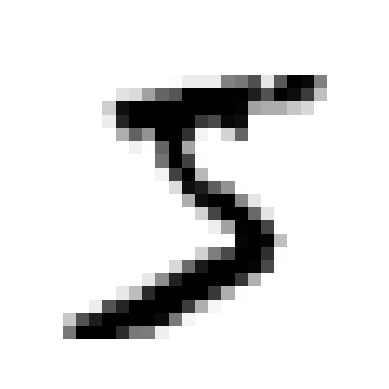

In [23]:
def plot_digit(image_data):
  image = image_data.reshape(28, 28)
  plt.imshow(image, cmap = "binary")
  plt.axis("off")
random_digit = X[0]
plot_digit(random_digit)
plt.show()

In [24]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [25]:
pipeline = Pipeline(steps=[
     ('pca', PCA(n_components=0.95)),
    ('classifier', KNeighborsClassifier())
])

In [26]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7]
}

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True)

In [28]:
model = GridSearchCV(estimator=pipeline, param_grid= param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(X_train, y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ..........................classifier__n_neighbors=3; total time=   7.4s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.5s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.1s
[CV] END ..........................classifier__n_neighbors=3; total time=   8.0s
[CV] END ..........................classifier__n_neighbors=3; total time=   9.5s
[CV] END ..........................classifier__n_neighbors=5; total time=   7.6s
[CV] END ..........................classifier__n_neighbors=5; total time=   8.9s
[CV] END ..........................classifier__n_neighbors=5; total time=   8.9s
[CV] END ..........................classifier__n_neighbors=5; total time=   7.3s
[CV] END ..........................classifier__n_neighbors=5; total time=   9.6s
[CV] END ..........................classifier__n_neighbors=7; total time=   8.9s
[CV] END ..........................classifier__n_

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('pca', PCA(n_components=0.95)),
                                       ('classifier', KNeighborsClassifier())]),
             param_grid={'classifier__n_neighbors': [3, 5, 7]},
             scoring='accuracy', verbose=2)

In [29]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.96      1.00      0.98      1135
           2       0.98      0.97      0.97      1032
           3       0.96      0.97      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.98      0.99      0.98       958
           7       0.96      0.97      0.97      1028
           8       0.99      0.94      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [32]:
print(model.best_params_)
print(model.best_score_)
print(model.best_estimator_)
print(model.best_estimator_.named_steps['pca'].n_components_)

{'classifier__n_neighbors': 3}
0.9741333333333333
Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('classifier', KNeighborsClassifier(n_neighbors=3))])
154


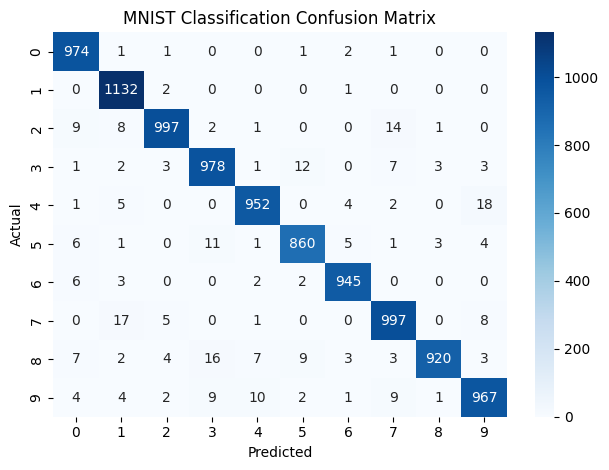


Test set accuracy: 97.22%


In [34]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

plt.title('MNIST Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.tight_layout()
plt.show()


test_score = model.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")